# Pancake Sort — Reverse Sorting
**Course:** Data Structures & Algorithms 1

## Implementation

In [2]:
def reverse(S, i):
    if len(S) == 0 or len(S) == 1:
        return S

    start = 0

    while start < i:
        temp = S[start]
        S[start] = S[i]
        S[i] = temp
        start += 1
        i -= 1
    
    return S

def maximum(S, i, j):
    if S[i] > S[j]:
        return i
    
    return j



def reverseSort(S):
    highestIndex = 0
    n = 0

    while n < len(S)-1:
        for i in range(1, len(S)-n):
            highestIndex = maximum(S, highestIndex , i)

        reverse(S, highestIndex)
        reverse(S, len(S)-n-1)
        n+=1
        highestIndex = 0

    return S

## Performance test

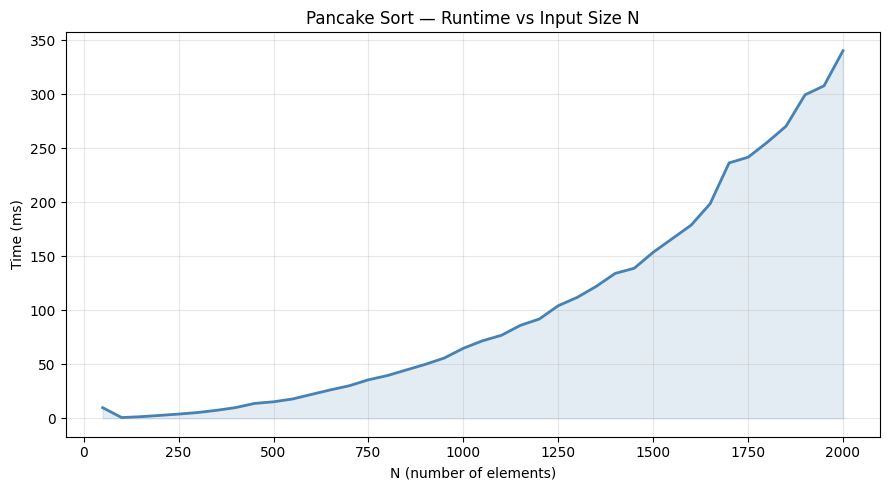

In [8]:
import time
import random

import matplotlib.pyplot as plt

random.seed(0)
sizes = list(range(50, 2001, 50))
times = []

for n in sizes:
    S = random.sample(range(n * 10), n)
    start = time.perf_counter()
    reverseSort(S)
    end = time.perf_counter()
    times.append((end - start) * 1000)

plt.figure(figsize=(9, 5))
plt.plot(sizes, times, color='steelblue', linewidth=2)
plt.fill_between(sizes, times, alpha=0.15, color='steelblue')
plt.xlabel('N (number of elements)')
plt.ylabel('Time (ms)')
plt.title('Pancake Sort — Runtime vs Input Size N')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('performance_plot.png', dpi=150)
plt.show()


## Complexity Analysis

### (c) Assuming `reverse` is O(1)

The outer loop runs $n-1$ times. The inner loop runs $n-k$ times on pass $k$:

$$\sum_{k=1}^{n-1} k = \frac{n(n-1)}{2} \in O(n^2)$$

**Total: O(n²)**

### (d) Actual complexity of `reverse`

`reverse(S, i)` swaps $\lfloor(i+1)/2\rfloor$ pairs → it is **O(i)**, worst case **O(n)**.  
Each outer pass calls `reverse` twice, adding O(n) per pass:

$$T(n) = \frac{n(n-1)}{2} + n(n-1) = \frac{3n(n-1)}{2} \in O(n^2)$$

**Actual total: O(n²)** — same class, but ~3× larger constant than the O(1) assumption.


## Unit Tests

In [ ]:
import unittest

class TestReverse(unittest.TestCase):

    def test_full_reversal(self):
        S = [1, 2, 3, 4, 5]                        
        reverse(S, 4)                                
        self.assertEqual(S, [5, 4, 3, 2, 1])        

    def test_prefix_reversal(self):
        S = [7, 5, 9, 13, 11]
        reverse(S, 3)
        self.assertEqual(S, [13, 9, 5, 7, 11])

    def test_index_zero_is_noop(self):
        S = [4, 3, 2, 1]
        reverse(S, 0)
        self.assertEqual(S, [4, 3, 2, 1])

    def test_single_element(self):
        S = [42]
        reverse(S, 0)
        self.assertEqual(S, [42])

    def test_empty_list(self):
        S = []
        result = reverse(S, 0) if S else S
        self.assertEqual(S, [])

    def test_negative_numbers(self):
        S = [-1, -5, -3]
        reverse(S, 2)
        self.assertEqual(S, [-3, -5, -1])


class TestMaximum(unittest.TestCase):

    def test_left_is_greater(self):
        S = [10, 3, 7]
        self.assertEqual(maximum(S, 0, 2), 0)

    def test_right_is_greater(self):
        S = [2, 9, 4]
        self.assertEqual(maximum(S, 0, 1), 1)

    def test_equal_returns_j(self):
        S = [5, 5, 5]
        self.assertEqual(maximum(S, 0, 2), 2)

    def test_negative_numbers(self):
        S = [-3, -1, -7]
        self.assertEqual(maximum(S, 0, 2), 0)


class TestReverseSort(unittest.TestCase):

    def test_typical_case(self):
        S = [3, 2, 5, 1, 4]
        self.assertEqual(reverseSort(S), [1, 2, 3, 4, 5])

    def test_already_sorted(self):
        S = [1, 2, 3, 4, 5]
        self.assertEqual(reverseSort(S), [1, 2, 3, 4, 5])

    def test_reverse_sorted(self):
        S = [5, 4, 3, 2, 1]
        self.assertEqual(reverseSort(S), [1, 2, 3, 4, 5])

    def test_empty_list(self):
        self.assertEqual(reverseSort([]), [])

    def test_single_element(self):
        self.assertEqual(reverseSort([7]), [7])

    def test_two_elements(self):
        self.assertEqual(reverseSort([2, 1]), [1, 2])

    def test_duplicates(self):
        S = [3, 1, 3, 2, 1]
        self.assertEqual(reverseSort(S), [1, 1, 2, 3, 3])

    def test_all_identical(self):
        self.assertEqual(reverseSort([4, 4, 4, 4]), [4, 4, 4, 4])

    def test_negative_numbers(self):
        S = [-3, -1, -4, -1, -5]
        self.assertEqual(reverseSort(S), [-5, -4, -3, -1, -1])

    def test_large_random(self):
        random.seed(42)
        S = random.sample(range(1000), 200)
        expected = sorted(S[:])
        self.assertEqual(reverseSort(S), expected)


# Run all tests and display results inline
loader = unittest.TestLoader()
suite = unittest.TestSuite()
for cls in [TestReverse, TestMaximum, TestReverseSort]:
    suite.addTests(loader.loadTestsFromTestCase(cls))
unittest.TextTestRunner(verbosity=2).run(suite)


test_empty_list (__main__.TestReverse.test_empty_list) ... ok
test_full_reversal (__main__.TestReverse.test_full_reversal) ... ok
test_index_zero_is_noop (__main__.TestReverse.test_index_zero_is_noop) ... ok
test_negative_numbers (__main__.TestReverse.test_negative_numbers) ... ok
test_prefix_reversal (__main__.TestReverse.test_prefix_reversal) ... ok
test_single_element (__main__.TestReverse.test_single_element) ... ok
test_equal_returns_j (__main__.TestMaximum.test_equal_returns_j) ... ok
test_left_is_greater (__main__.TestMaximum.test_left_is_greater) ... ok
test_negative_numbers (__main__.TestMaximum.test_negative_numbers) ... ok
test_right_is_greater (__main__.TestMaximum.test_right_is_greater) ... ok
test_all_identical (__main__.TestReverseSort.test_all_identical) ... ok
test_already_sorted (__main__.TestReverseSort.test_already_sorted) ... ok
test_duplicates (__main__.TestReverseSort.test_duplicates) ... ok
test_empty_list (__main__.TestReverseSort.test_empty_list) ... ok
test_l

<unittest.runner.TextTestResult run=20 errors=0 failures=0>